<a href="https://colab.research.google.com/github/hollyxue05/AMS-332-Physiological-Systems-Modeling/blob/main/Working_with_random_numbers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Working with random numbers

In this notebook we expand our computational toolbox to working with random numbers, using a few very simply "toy" problems.

You should implement your own Python code in the appropriate block and ensure you are able to answer all relevant questions.

Please note that some questions may require you to work "by hand", so have a notepad or notebook handy.




# Random variables.

We have discussed the idea of a random variable as a number that takes on a *random* value following some probability distribution.

We work with these using the `np.random` module, which is automatically loaded when we initialized  `numpy` and `matplotlib`.


In [14]:
import numpy as np
from matplotlib import pyplot as plt


# Generating random values

The `np.random` module contains a whole set of functions that can "automatically" give you a random value drawn from a diverse set of probablity distributions.

However, we will begin with a simple base case, the `np.random.rand()` function, which returns a random value from the uniform distribution between 0 and 1.

As seen here, each time we execute this function, we get a different random number!

The distribution can be visualized using the `hist` function from matplotlib.

0.5569120852219639
0.8336395941983674
0.41194788314898156
0.735263373271697
0.02124218342444184
0.3278168722276493
0.06624694339477322
0.7511297982841776
0.6192236983721602


Text(0, 0.5, 'Frequency')

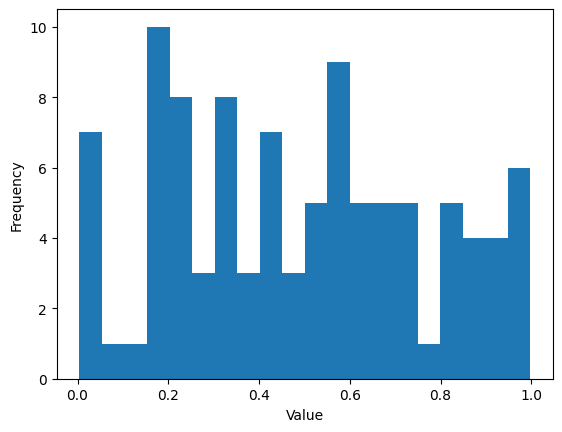

In [15]:
for i in range(1,10):
  print(np.random.rand())

randomdataarray = np.random.rand(100)
plt.hist(randomdataarray,bins=20)
plt.xlabel("Value")
plt.ylabel("Frequency")

## Tranforming random values.

* Generate an array of 10,000 random numbers between 0 and 1.0, and plot this as a histogram with 10 bins (i.e. intervals of 0.1).
* Transform this array according to $y= -2 + 4*x$, and plot the result as a histogram with 40 bins.
* Transform the original array according to $z = -ln(x)$, and plot the result with 40 bins.



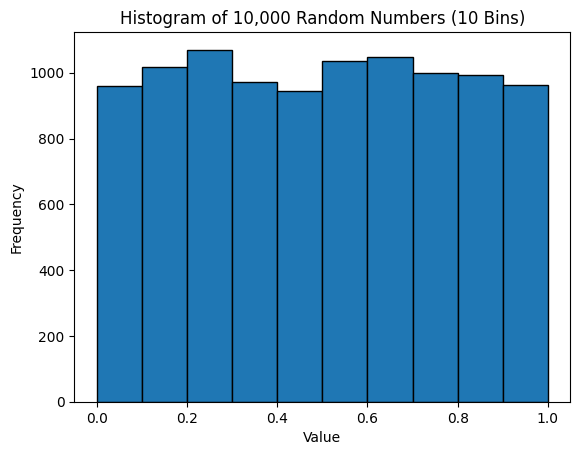

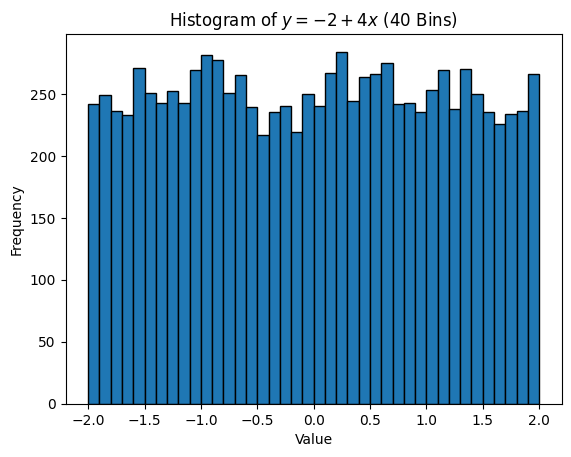

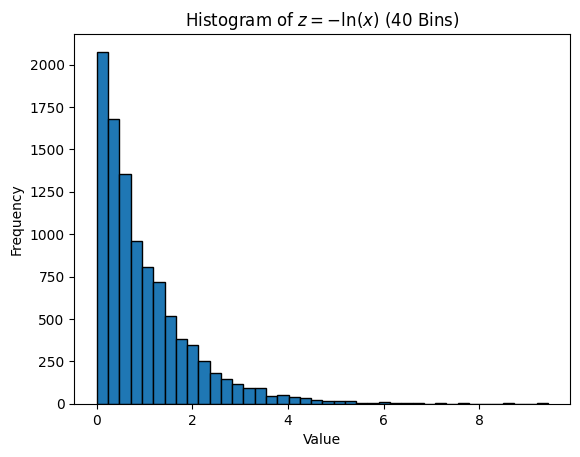

In [16]:
import numpy as np
from matplotlib import pyplot as plt

# Generate an array of 10,000 random numbers between 0 and 1.0
random_data_array = np.random.rand(10000)

# 10 bins
plt.hist(random_data_array, bins=10, edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of 10,000 Random Numbers (10 Bins)")
plt.show()

# Transform array according to y = -2 + 4 * x
y = -2 + 4 * random_data_array

# 40 bins
plt.hist(y, bins=40, edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of $y = -2 + 4x$ (40 Bins)")
plt.show()

# Transform the original array according to z = -ln(x)
z = -np.log(random_data_array)

# 40 bins
plt.hist(z, bins=40, edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of $z = -\\ln(x)$ (40 Bins)")
plt.show()

## Discuss your observations

How is the random variable $Y$ distributed?  How is the random variable $Z$ distributed?

How do you think your histograms would change if you reduced the number of data points?  What about if you increased number?

How do you think your histograms would change if you reduced the number of data *bins*?  What about is you increased the number?


### Enter your answers here:

Random variable $Y$ is distributed fairly uniformly, with values ranging from -2 to 2. Random variable $Z$ follows an exponential distribution thanks to the natural log transformation.

If you increase the number of data points, random variables $X$ and $Y$ will show more uniform plots. The opposite will occur if you decrease the number of data points. However, I anticipate that random variable $Z$ will retain its exponential disribution shape regardless of the number of data points.

If you reduced the number of bins significantly, you significantly reduce the amount of detail that the plots can provide. This can make it more difficult to identify trends. Increasing the number of bins can increase the amount of detail in the plot. However, if you increase the number of bins without also adding data points, it is possible for certain bins of the histogram to be missing values. This creates unwanted breaks in the resulting plot.  


## Working with random variables conditionally.

The `if` function lets us execute some code only when a certain condition is met, for example:
```
a = 2.5
if (a < 2.0):
  print("No, 2.5 is *not* less than 2.0")
else:
  print("Indeed, 2.5 is not less than 2.0")
```

As a first example:

Initialize a counter variable to 0.
Then, in a loop of 1000 steps:
* Generate two random values between 0 and 1 (uniformly distributed), $a$ and $b$.
* Compute $c^2 = a^2 + b^2$, then do the following:
* If $c^2 <= 1$, plot $(a,b)$ as a blue dot, and add 1 to the counter variable.
* If $c^2 > 1$, plot $(a,b)$ as a red dot, and do *not* add anything to the counter variable.

Finally, divide your counter value by 1000, then multiply the answer by 4, and display the answer.


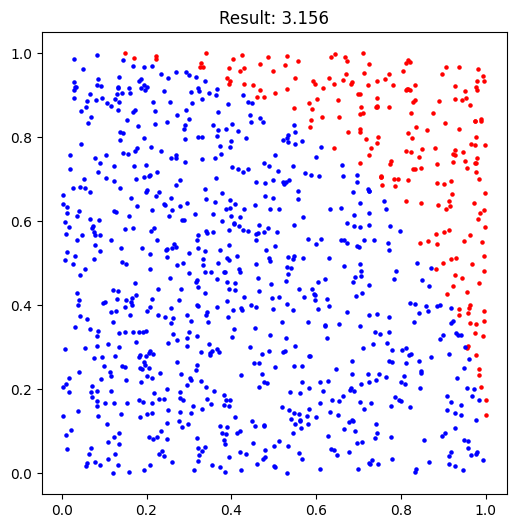

In [21]:
import numpy as np
from matplotlib import pyplot as plt

counter = 0
n_steps = 1000

plt.figure(figsize=(6, 6))

for _ in range(n_steps):
    a = np.random.rand()
    b = np.random.rand()

    # check if the plot is within the bounds
    if (a**2 + b**2) <= 1:
        plt.scatter(a, b, color='blue', s=5)
        counter += 1
    else:
        plt.scatter(a, b, color='red', s=5)

# calculate the result
final_answer = (counter / n_steps) * 4

plt.title(f"Result: {final_answer}")
plt.show()

## Discuss your observations

What does your plot look like at the end?  What do you notice about the number you computed?

Discuss *why* your simulation gives you these results.

### Enter your answer here

The resulting plot looks like a quadrant of a circle. I am reminded of the unit circle specifically because the plot is a circle with a radius of one. The computed value is also close to $\pi$. The simulation calculates a value close to $\pi$ because of the $c^2 = a^2 + b^2, c^2 \geq  1, c^2 < 1$ conditions. $a$ and $b$ are bounded between $0$ and $1$, so substituting $1$ for $c$, the resulting equation is $1 \geq a^2 + b^2$. This equation is the definition for a circle with radius $1$. As a result, any combination of $a$ and $b$ that satisfy this condition will be colored blue. The total number of blue dots divided by the total number of dots (1000) results in the probability that a random combination of $a$ and $b$ values will be included in one quadrant of the unit circle. Multiplying this value by $4$ will result in the probability of a random point with $x ∈ [-1,1]$ and $y ∈ [-1,1]$ being in the unit circle. This probability is equivalent to the ratio between the unit circle and unit square, more commonly known as $\pi$.

## A conditional average

Here, we work with random numbers to meet some *varying* condition.   We will compute the average of a set of random variables that are larger than some other random variables.

* Set two initial values to zero, one to count a number of matches and the other to hold a cummulative sum.
* Compute an array of 10000 random values, $x$, uniformly distributed between 0 and 1.
* Create a `for` loop that walks through each of these and compares it to a new random number, $y$.   If the first value is larger than the second, add one to the count of matches and add $x$ to the cummulative sum.
* After the loop, divide the cummulative sum by the number of matches and report the average.


In [30]:
import numpy as np

matches = 0
cumulative_sum = 0

# Compute an array of 10000 random values,  x , uniformly distributed between 0 and 1.
x_values = np.random.rand(10000)

for x in x_values:
    # compare to new random variable y
    y = np.random.rand()

    if x > y:
        matches += 1
        cumulative_sum += x

# calculate and report the average
if matches > 0:
    average = cumulative_sum / matches
    print(f"Average of x where x > y: {average}")

Average of x where x > y: 0.6656077531603131


## Discuss:

* What is your final answer?
* Does this number make sense to you?
* Explain why.

### Enter answers here

After running the code a couple of times, the answer appears to always hover around $0.66$ or $\frac{2}{3}$. If you randomly pick two numbers between 0 and 1, the probability that $x > y$ is $1/2$. Note that when this condition has been met, $x$ is biased toward the higher end of the range. As a result, the probability density for $x$ is more likely to be greater than $\frac{1}{2}$.